In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

In [15]:
score_path = './scores/all_scores.csv'
df_scores = pd.read_csv(score_path)
display(df_scores.shape)
df_scores.head()

(2304, 3)

,image_name,score,user
0,06618305_PROC_L_MLO_20230421152741,10,guilherme muniz
1,06618305_PROC_R_MLO_20230421152905,10,guilherme muniz
2,08056979_PROC_L_MLO_20230805161749,10,guilherme muniz
3,08056979_PROC_R_MLO_20230805161840,8,guilherme muniz
4,09759995_PROC_L_MLO_20230910220321,10,guilherme muniz


In [32]:
count_already_scored_df = df_scores[['image_name', 'user']].groupby('image_name').count()
print("Quantidade de imagens já avaliadas por 3 usuários: ", count_already_scored_df[count_already_scored_df['user']==3].shape[0], "/", count_already_scored_df.shape[0])

count_users_scores_df = df_scores[['image_name', 'user']].groupby('user').count()
count_users_scores_df.sort_values(by='image_name', inplace=True, ascending=False)
count_users_scores_df

Quantidade de imagens já avaliadas por 3 usuários:  712 / 800


,image_name
user,
vitor,800
ana camilo,275
luana,221
ruancampello,197
fernando_davila,120
joaovitorsampaio,111
miguel,110
guilherme-lopes,103
samuel ismael,100


In [17]:
scored_users_list = list(count_users_scores_df.index)
volunteers_list = ['ana camilo', 'fernando_davila', 'gabrielcampelo', 'guilherme-lopes', 'joaoboscoduarte',
                   'joaovitorsampaio', 'mateus dias', 'miguel', 'ruancampello', 'samuel ismael', 'sarahcalixto','beatriz almeida'] 


In [28]:
no_volunteers_users = [user for user in scored_users_list if user not in volunteers_list]
#print('não voluntários', no_volunteers_users)
assert len(no_volunteers_users) == 3

volunteers_wto_score = [volunter for volunter in volunteers_list if volunter not in scored_users_list]
if len(volunteers_wto_score):
    print('que faltam começar a fazer score: ', volunteers_wto_score)
else:
    print("todos fizeram!!")

todos fizeram!!


In [19]:
# ver quantas avaliações precisam ser feitas

In [20]:
df_mean = df_scores.groupby('image_name', as_index=False)['score'].mean()
df_mean.rename(columns={'score': 'mean_score'}, inplace=True)

display(df_mean.shape)
df_mean.head()

(800, 2)

,image_name,mean_score
0,06618305_PROC_L_MLO_20230421152741,10.0
1,06618305_PROC_R_MLO_20230421152905,10.0
2,08056979_PROC_L_MLO_20230805161749,10.0
3,08056979_PROC_R_MLO_20230805161840,7.0
4,09759995_PROC_L_MLO_20230910220321,10.0


In [21]:
select_imgs_path = './random_selected_MLO.csv'
df_select_imgs = pd.read_csv(select_imgs_path)
df_select_imgs.head()

,Dummy_ID,birads_density,Files_L,Subfolder_L,Files_R,Subfolder_R
0,4537110,1,88,4537110_PROC_L_MLO_20130105193311,87,4537110_PROC_R_MLO_20130105193420
1,88687259,1,66,88687259_PROC_L_MLO_20171118153926,63,88687259_PROC_R_MLO_20171118154100
2,4294555,1,84,4294555_PROC_L_MLO_20121008195815,89,4294555_PROC_R_MLO_20121008195521
3,92103288,1,81,92103288_PROC_L_MLO_20191102140742,79,92103288_PROC_R_MLO_20191102140844
4,87117265,1,78,87117265_PROC_L_MLO_20160227210956,79,87117265_PROC_R_MLO_20160227210832


In [22]:
df_L = df_select_imgs[['birads_density','Subfolder_L']].rename(columns={'Subfolder_L':'image_name'})
df_R = df_select_imgs[['birads_density','Subfolder_R']].rename(columns={'Subfolder_R':'image_name'})
df_select_imgs = pd.concat((df_L, df_R), axis=0).reset_index(drop=True)
display(df_select_imgs.shape)
df_select_imgs.head()

(800, 2)

,birads_density,image_name
0,1,4537110_PROC_L_MLO_20130105193311
1,1,88687259_PROC_L_MLO_20171118153926
2,1,4294555_PROC_L_MLO_20121008195815
3,1,92103288_PROC_L_MLO_20191102140742
4,1,87117265_PROC_L_MLO_20160227210956


In [23]:
df_merge = pd.merge(df_mean, df_select_imgs, on='image_name', how='inner')
display(df_merge.shape)
df_merge.head()

(800, 3)

,image_name,mean_score,birads_density
0,06618305_PROC_L_MLO_20230421152741,10.0,2
1,06618305_PROC_R_MLO_20230421152905,10.0,2
2,08056979_PROC_L_MLO_20230805161749,10.0,4
3,08056979_PROC_R_MLO_20230805161840,7.0,4
4,09759995_PROC_L_MLO_20230910220321,10.0,3


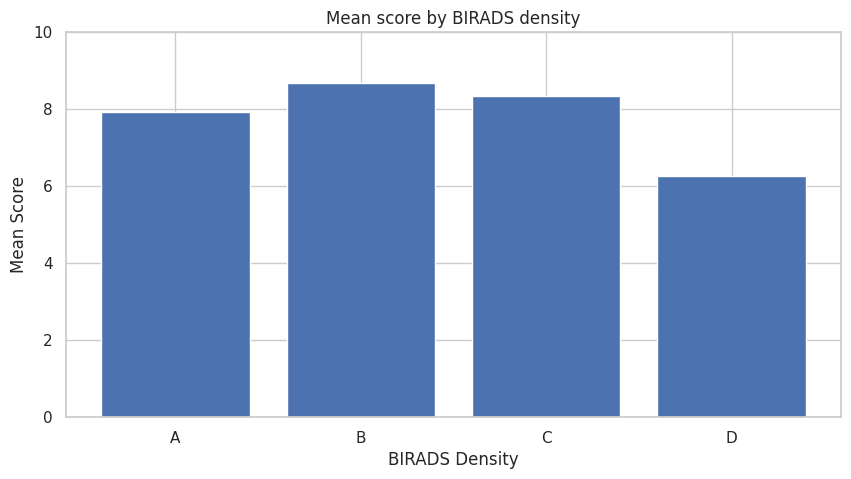

,birads_density,mean_score
0,1,7.920833
1,2,8.679167
2,3,8.340833
3,4,6.276667


In [24]:
# Agrupa por birads_density e calcula média
birads_mean = df_merge.groupby('birads_density', as_index=False)['mean_score'].mean()

# Plota gráfico de barras
plt.figure(figsize=(10, 5))
birads_densisty_letter = ['A', 'B', 'C', 'D']
plt.bar(birads_densisty_letter, birads_mean['mean_score'])
plt.xlabel('BIRADS Density')
plt.ylabel('Mean Score')
plt.grid(True)
plt.title('Mean score by BIRADS density')
#plt.xticks(birads_mean['birads_density'])  # garante que o X tenha todos os valores
plt.ylim(0, 10)  # já que score é de 0 a 10
plt.show()
display(birads_mean)


In [25]:
birads_mean['birads_density']

0    1
1    2
2    3
3    4
Name: birads_density, dtype: int64

In [26]:
birads_densisty_letter

['A', 'B', 'C', 'D']